
# Stylized facts of Brazil

**Authorship:** FISLAC Group – Inter-American Development Bank. 
**Date:** Nov 2025.

### Objective:
 - Identify the trends and cycles of the Brazil economy.
 - Compute descriptive statistics of the cycles.



In [1]:
import Pkg; Pkg.add("Plots")
import Pkg; Pkg.add("StatsBase")
import Pkg; Pkg.add("PrettyTables")


    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`


In [2]:
import Pkg; Pkg.add("XLSX")
import Pkg; Pkg.add("DataFrames")
using XLSX, DataFrames, StatsBase, Plots, LinearAlgebra, PrettyTables, Printf


   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.8/Project.toml`
  No Changes to `~/.julia/environments/v1.8/Manifest.toml`


The Hodrick–Prescott filter minimizes
$$
\min_{\{g_t\}_{t=1}^T} \sum_{t=1}^T (y_t - g_t)^2 + 
\lambda \sum_{t=2}^{T-1} (g_{t+1} - 2g_t + g_{t-1})^2
$$


In [3]:
function hpfilter(y::AbstractVector; lambda::Real) #It takes as arguments a data vector and the Lagrange multiplier.
    T = length(y) 
    I = Matrix(LinearAlgebra.I, T, T)
    D = zeros(T - 2, T) #Matrix of second differences
    for i in 1:(T - 2) 
        D[i, i] = 1 #coeficientes das fórmula de HP
        D[i, i + 1] = -2
        D[i, i + 2] = 1
    end
    A = I + lambda * (D' * D)
    tendencia = A \ y
    ciclo = y - tendencia
    return ciclo, tendencia
end

hpfilter (generic function with 1 method)

In [4]:
using Dates, DataFrames

# For dates like "1996Q2" manipula as datas
function quarter_to_date(q_string)
    year = parse(Int, q_string[1:4])
    quarter = parse(Int, q_string[6])
    month = (quarter - 1) * 3 + 1  # Q1->1, Q2->4, Q3->7, Q4->10
    return Date(year, month, 1)
end

#df.fecha = quarter_to_date.(df.trimestre)

quarter_to_date (generic function with 1 method)

In [6]:
# Import data
file = XLSX.readtable("Brasil_data.xlsx", "Hoja1")
data = DataFrame(file)
Vnames = ["PIB", "Consumo", "Investimento", "Exportações", "Importações", "Gasto Público"]
data.trimestre = quarter_to_date.(data.year)
select!(data, :trimestre, :)
select!(data, Not(:year)) #muda o formato das datas
periodo = data[:, 1]
V1 = log.(Matrix(data[:, 2:7])) #transforma tudo em log; pega todas as linhas, mas colunas de 2 a 7, pq a primeira são as datas

117×6 Matrix{Float64}:
 25.9033  25.4689  24.2541  23.2616  23.4427  24.1565
 25.9373  25.4972  24.2605  23.2815  23.5779  24.2934
 25.9299  25.5025  24.2176  23.1658  23.5854  24.3213
 25.9399  25.5462  24.3044  23.1276  23.5121  24.0994
 25.9453  25.5346  24.3275  23.3513  23.6114  24.117
 25.9561  25.5101  24.3063  23.3694  23.6758  24.3199
 25.9664  25.5167  24.2558  23.2858  23.618   24.3981
 25.9462  25.5406  24.3035  23.2624  23.5616  24.1374
 25.9626  25.5035  24.3124  23.3675  23.5643  24.314
 25.9617  25.505   24.2721  23.3417  23.642   24.389
  ⋮                                            ⋮
 26.5079  26.0273  24.6926  24.8293  24.6448  24.833
 26.5087  26.0491  24.7023  24.7871  24.6369  24.7904
 26.5119  26.0551  24.6759  24.7559  24.6227  24.8282
 26.5206  26.0838  24.7324  24.7187  24.6643  24.7944
 26.5358  26.0673  24.7401  24.8428  24.7581  24.8912
 26.5436  26.0986  24.8074  24.8725  24.8788  24.8518
 26.5443  26.0956  24.7809  24.8428  24.8528  24.8935
 26.5573  26.1

In [7]:
data

Row,trimestre,PIB,C,I,X,M,G
,Date,Any,Any,Any,Any,Any,Any
1,1996-04-01,1.7769e11,1.15076e11,3.41519e10,1.26582e10,1.51715e10,3.09751e10
2,1996-07-01,1.83826e11,1.18387e11,3.43714e10,1.29127e10,1.73675e10,3.55225e10
3,1996-10-01,1.82476e11,1.19015e11,3.29297e10,1.15022e10,1.74984e10,3.65279e10
4,1997-01-01,1.84316e11,1.24332e11,3.59156e10,1.10715e10,1.62624e10,2.92586e10
5,1997-04-01,1.85312e11,1.22895e11,3.67529e10,1.38469e10,1.79591e10,2.97769e10
6,1997-07-01,1.87328e11,1.19923e11,3.59828e10,1.40996e10,1.91538e10,3.64759e10
7,1997-10-01,1.89259e11,1.2072e11,3.42092e10,1.29684e10,1.80796e10,3.94411e10
8,1998-01-01,1.85484e11,1.23632e11,3.58808e10,1.2669e10,1.70877e10,3.03903e10
9,1998-04-01,1.88535e11,1.19132e11,3.62042e10,1.40726e10,1.71341e10,3.62603e10


In [8]:
periodo

117-element Vector{Date}:
 1996-04-01
 1996-07-01
 1996-10-01
 1997-01-01
 1997-04-01
 1997-07-01
 1997-10-01
 1998-01-01
 1998-04-01
 1998-07-01
 ⋮
 2023-04-01
 2023-07-01
 2023-10-01
 2024-01-01
 2024-04-01
 2024-07-01
 2024-10-01
 2025-01-01
 2025-04-01

In [9]:
log(data.PIB[1])

25.90330736518078

In [10]:

size(V1,2)

6

In [15]:
data.PIB[1, 1]


1.7769019e11

In [17]:
df_tendencia = DataFrame(trimestre = data.trimestre)
df_ciclo = DataFrame(trimestre = data.trimestre)
# Filtro HP
Tendencia = similar(V1) #Creates a matrix without initial values, of the same size and type as V1.
Ciclo = similar(V1)

for j in 1:size(V1, 2) #The 2 refers to the columns of V1.
    ciclo, tendencia = hpfilter(V1[:, j]; lambda=1600)
    Tendencia[:, j] = tendencia
    Ciclo[:, j] = ciclo
end

In [18]:
for (j, nombre) in enumerate(Vnames)
    df_tendencia[!, nombre] = Tendencia[:, j]
    df_ciclo[!, nombre] = Ciclo[:, j]
end

In [19]:
df_tendencia

Row,trimestre,PIB,Consumo,Investimento,Exportações,Importações,Gasto Público
,Date,Float64,Float64,Float64,Float64,Float64,Float64
1,1996-04-01,25.9208,25.4971,24.2651,23.1354,23.4842,24.2163
2,1996-07-01,25.925,25.5001,24.2651,23.1685,23.5084,24.2262
3,1996-10-01,25.9291,25.5031,24.2651,23.2016,23.5326,24.2361
4,1997-01-01,25.9333,25.5061,24.265,23.2349,23.5567,24.246
5,1997-04-01,25.9374,25.509,24.265,23.2685,23.5809,24.2558
6,1997-07-01,25.9416,25.5118,24.2648,23.3026,23.6052,24.2657
7,1997-10-01,25.9457,25.5147,24.2646,23.3373,23.6296,24.2754
8,1998-01-01,25.9498,25.5175,24.2645,23.3726,23.6541,24.2849
9,1998-04-01,25.9539,25.5203,24.2643,23.4087,23.6789,24.2942


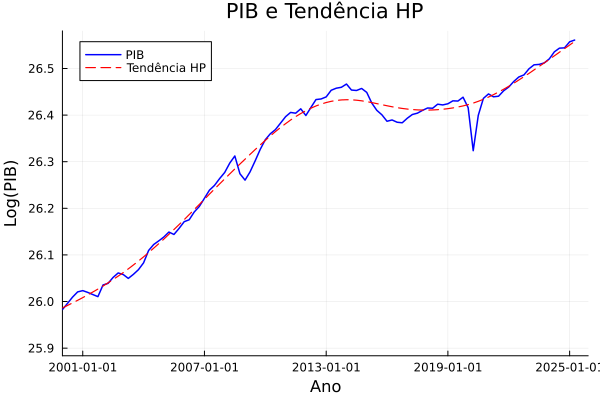

In [32]:
# Gráfico PIB y su tendencia 
using Plots, Dates
plot(
    periodo[1:length(periodo)], V1[1:length(periodo), 1],
    label = "PIB",
    linewidth = 1.5,
    color = :blue,
    grid = true,
)
plot!(
    periodo[1:length(periodo)], Tendencia[1:length(periodo), 1],
    label = "Tendência HP",
    linewidth = 1.2,
    linestyle = :dash,
    color = :red,
)
xlims!((Date(2000, 1, 1), Date(2025, 12, 1)))
#ylims!(24, 27)
title!("PIB e Tendência HP")
xlabel!("Ano")
ylabel!("Log(PIB)")
#savefig("Tendencia PIB.png") 

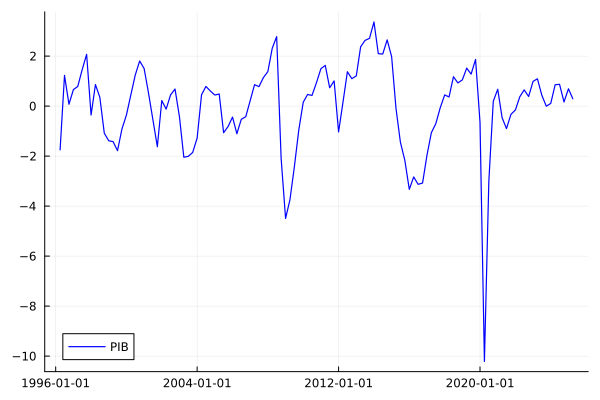

In [33]:
plt = plot(
        periodo[1:length(periodo)], Ciclo[1:length(periodo), 1] .* 100,
        label = "PIB",
        linewidth = 1.2,
        color = :blue,
        grid = true,
    )
#savefig("Ciclo PIB.png")   

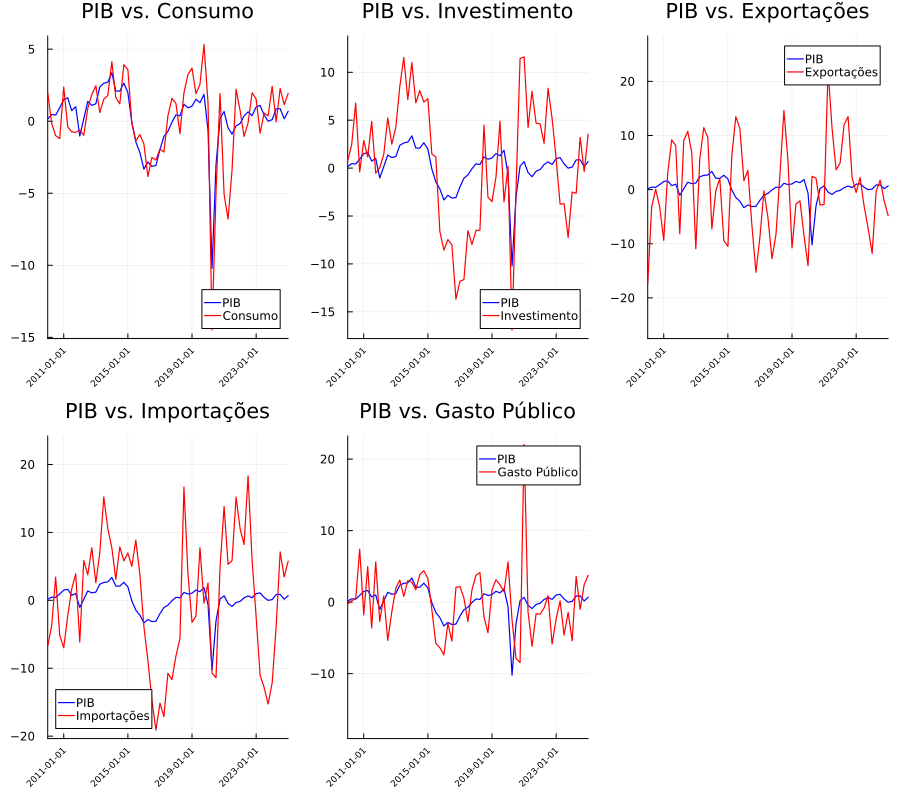

In [34]:
using Plots

nvars = length(Vnames)
nrows, ncols = 2, 3
p = []

for j in 2:nvars
    plt = plot(
        df_ciclo.trimestre, df_ciclo.PIB .* 100,
        label = "PIB",
        linewidth = 1.2,
        color = :blue,
        grid = true,
        xrotation = 45,
        xtickfontsize = 6,
        xlims = (Date(2010, 1, 1), Date(2024, 12, 31)) 
    )
    plot!(
        df_ciclo.trimestre, df_ciclo[:, Vnames[j]] .* 100,
        label = Vnames[j],
        linewidth = 1.2,
        color = :red,
    )
    title!(plt, "PIB vs. " * Vnames[j])
    push!(p, plt)
end

plot(p..., layout = (nrows, ncols), size = (900, 800))
#savefig("Ciclo vs Tend .png") 

In [35]:
# Desviaciones estándar
desv_abs = [std(Ciclo[:, j]) for j in 1:size(Ciclo, 2)]
desv_rel = desv_abs ./ desv_abs[1]

# Persistencia
persist = [autocor(Ciclo[:, j], [1])[1] for j in 1:size(Ciclo, 2)]

# Correlaciones estáticas
corr_est = [cor(Ciclo[:, 1], Ciclo[:, j]) for j in 1:size(Ciclo, 2)]

# Correlaciones dinámicas
lags = -5:5 #crea un rango
corr_din = fill(NaN, size(Ciclo, 2), length(lags))

for j in 1:size(Ciclo, 2)  
    for (h, lag) in enumerate(lags) #h es el índice en la lista de lags, lag es el valor del lag, enumerate devuelve pares (índice, valor) de lags
        if lag >= 0  
            y = Ciclo[1:end - lag, 1]
            x = Ciclo[1 + lag:end, j]
        else
            y = Ciclo[1 - lag:end, 1]
            x = Ciclo[1:end + lag, j]
        end

        if length(y) > 2 #Solo se calcula la correlación si se tienen más de 2 de observaciones
            corr_din[j, h] = cor(y, x) #Almacena la corrlación entre la variable j con el PIB para cada lag
        else
            corr_din[j, h] = NaN
        end
    end
end

# Nombres de los lags 
lagNames = ["t$(lag >= 0 ? "+" : "")$lag" for lag in lags] # ? es el operador si, usa el símbolo "+", si no, usa una cadena vacía ""

# Tabla de resultados 
df = DataFrame(
    Variable = Vnames,
    Volatilidad = desv_abs,
    Vol_Relativa = desv_rel,
    Persistencia = persist,
    CorrEstatica = corr_est,
)

# Agregar las correlaciones dinámicas a la tabla
for (i, name) in enumerate(lagNames)
    df[!, name] = corr_din[:, i]
end

In [36]:
headers = names(df)
data_matrix = Matrix(df)

pretty_table(data_matrix;
    header = headers,
    formatters = ft_printf("%.2f"),
    alignment = :c,
    header_alignment = :c
)

┌───────────────┬─────────────┬──────────────┬──────────────┬──────────────┬───────┬───────┬───────┬───────┬──────┬──────┬──────┬──────┬───────┬───────┬───────┐
│   Variable    │ Volatilidad │ Vol_Relativa │ Persistencia │ CorrEstatica │  t-5  │  t-4  │  t-3  │  t-2  │ t-1  │ t+0  │ t+1  │ t+2  │  t+3  │  t+4  │  t+5  │
├───────────────┼─────────────┼──────────────┼──────────────┼──────────────┼───────┼───────┼───────┼───────┼──────┼──────┼──────┼──────┼───────┼───────┼───────┤
│      PIB      │    0.02     │     1.00     │     0.62     │     1.00     │ -0.08 │ -0.01 │ 0.11  │ 0.29  │ 0.63 │ 1.00 │ 0.63 │ 0.29 │ 0.11  │ -0.01 │ -0.08 │
│    Consumo    │    0.03     │     1.46     │     0.37     │     0.68     │ -0.08 │ -0.04 │ 0.01  │ 0.11  │ 0.37 │ 0.68 │ 0.41 │ 0.19 │ 0.24  │ 0.18  │ -0.01 │
│ Investimento  │    0.06     │     3.46     │     0.53     │     0.67     │ -0.06 │ -0.02 │ 0.04  │ 0.23  │ 0.44 │ 0.67 │ 0.46 │ 0.19 │ 0.09  │ 0.06  │ -0.01 │
│  Exportações  │    0.10     │   

In [37]:
XLSX.writetable(
    "Hechos_Estilizados_Brasil.xlsx",
    df;
    overwrite=true,
    sheetname="Resultados"
)